# 10 — Exact Roman material ledgers

This workbook normalizes every flow to **one completed heavy-catalyst traversal**. It separates loaded, burned, recovered, and lost N15/D/T; expands DD tritium makeup into both branches; and derives the neutron-recovery condition for deuterium parity.

The output is conditional on the Workbook-40 target cards. It does not claim that the required neutron-recovery probabilities are physically achieved; Workbook 45 must calculate them.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

repo_root = Path.cwd()
while repo_root.name != 'CNO' and repo_root != repo_root.parent:
    repo_root = repo_root.parent
source_root = repo_root / 'analysis' / 'src'
if str(source_root) not in sys.path:
    sys.path.insert(0, str(source_root))

from cno_sweep import (
    constantine_efficiency_for_d_parity, driver_support_from_targets,
    equal_success_probability_floor, evaluate_roman_closure,
    load_builtin_reactions, roman_phase_one_target_sets,
)
from cno_sweep.reaction_data import sum_reactions

pd.set_option('display.max_columns', 40)
pd.set_option('display.precision', 6)
selected_sets, _ = roman_phase_one_target_sets()
supports = {case: driver_support_from_targets(case, targets) for case, targets in selected_sets.items()}
print('Loaded exact ledgers for:', ', '.join(supports))

Loaded exact ledgers for: likely, conservative


## Ideal nuclear sum

The accepted mainline includes five central reactions, three beta decays, Trajan, and capture of Constantine's neutron on one additional proton. The exact ideal sum is

$$6p \rightarrow D + \alpha + 3e^+ + 3\nu_e + \text{gamma energy}.$$

Before neutron capture it is $5p\rightarrow n+\alpha+3e^++3\nu_e$. This is material bookkeeping, not a claim that the neutron escapes or the D survives.

In [2]:
reaction_ids = [
    'c12-p-g-n13', 'n13-beta-c13', 'c13-a-n-o16', 'n-p-g-d',
    'o16-p-g-f17', 'f17-beta-o17', 'o17-p-a-n14',
    'n14-p-g-o15', 'o15-beta-n15', 'n15-p-a-c12',
]
reactions = load_builtin_reactions()
ideal_net = sum_reactions([reactions[name] for name in reaction_ids])
pd.Series(ideal_net, name='net nuclei / ideal traversal').to_frame()

,net nuclei / ideal traversal
gamma,4
h1,-6
eplus,3
nu_e,3
he4,1
d,1


## Exact N15 and DT support inherited from Workbook 40

One traversal produces exactly one N15 and must ultimately burn exactly one N15 back to C12. The target-card optimizer uses slightly less than that one-N15 allowance. The remainder is available for deliberate overdrive or failed-attempt reserve; it is not a second source of energy.

Driver DT below includes the DT vein loading associated with exactly one total N15 burn. Central DT is the sum of all five late kernels per successful traversal.

In [3]:
support_rows = []
allocation_rows = []
for case, support in supports.items():
    support_rows.append({
        'case': case,
        'calculated N15 burn': support.calculated_n15_burn_per_traversal,
        'N15 reserve': support.n15_burn_reserve_per_traversal,
        'N15 loaded for exact burn': support.n15_loaded_for_exact_burn,
        'N15 unburned': support.n15_unburned_after_exact_burn,
        'driver DT loaded': support.driver_dt_loaded_for_exact_n15_burn,
        'driver DT burned': support.driver_dt_burned_for_exact_n15_burn,
        'central DT loaded': support.central_dt_loaded_per_traversal,
        'central DT burned': support.central_dt_burned_per_traversal,
        'total DT loaded': support.total_dt_loaded_per_traversal,
        'total DT burned': support.total_dt_burned_per_traversal,
    })
    for recipe, allocation in support.n15_allocations.items():
        allocation_rows.append({'case': case, 'recipe': recipe, 'N15 burned / traversal': allocation})
display(pd.DataFrame(support_rows).set_index('case'))
pd.DataFrame(allocation_rows).set_index(['case', 'recipe'])

,calculated N15 burn,N15 reserve,N15 loaded for exact burn,N15 unburned,driver DT loaded,driver DT burned,central DT loaded,central DT burned,total DT loaded,total DT burned
case,,,,,,,,,,
likely,0.996912,0.003088,2.000000,1.000000,0.111200,0.088960,2.178488e-04,1.089244e-04,0.111418,0.089069
conservative,0.959266,0.040734,2.857143,1.857143,0.228571,0.137143,1.734487e-07,5.203460e-08,0.228572,0.137143


N15 burned / traversal
case         recipe                             
likely       caesar                     0.034569
             constantine                0.013274
             aurelian                   0.262672
             scipio                     0.017058
             diocletian                 0.669339
conservative caesar                     0.022012
             constantine                0.013137
             aurelian                   0.455698
             scipio                     0.017425
             diocletian                 0.450995

In [4]:
retry_rows = []
for case, support in supports.items():
    for failed_burn in (1.0, 0.5, 0.1, 0.0):
        retry_rows.append({
            'case': case, 'driver burn on failed attempt': failed_burn,
            'equal shot-success probability floor': equal_success_probability_floor(support, failed_burn),
        })
pd.DataFrame(retry_rows).set_index(['case', 'driver burn on failed attempt'])

equal shot-success probability floor
case         driver burn on failed attempt                                      
likely       1.0                                                        0.996912
             0.5                                                        0.993844
             0.1                                                        0.969959
             0.0                                                        0.000000
conservative 1.0                                                        0.959266
             0.5                                                        0.921720
             0.1                                                        0.701932
             0.0                                                        0.000000

## Fully expanded D/T support ledger

Let $L$ be DT pairs irreversibly burned or lost after attempted recovery. Closing the tritium inventory with equal DD branches requires:

- $L$ reactions through $D+D\rightarrow p+T$;
- $L$ companion reactions through $D+D\rightarrow n+{}^3He$;
- therefore $4L$ D for tritium production;
- plus $L$ D used in the DT inventory itself.

Thus $D_{consumed}=5L$. With perfect recovery of unburned DT, $L=P$, the burned DT-pair count. The recoverable production is

$$D_{recovered}=\eta_C + P\eta_{DT}+L\eta_{DD},$$

where $\eta_C$ is the fate of the one Constantine neutron.

In [5]:
scenario_rows = []
scenarios = {
    'Constantine threshold; no auxiliary neutron credit': None,
    '80% recovery for all neutron sources': (0.8, 0.8, 0.8),
    'perfect neutron recovery': (1.0, 1.0, 1.0),
}
for case, support in supports.items():
    for label, efficiencies in scenarios.items():
        if efficiencies is None:
            eta_c = constantine_efficiency_for_d_parity(support, eta_dt_n_to_d=0.0, eta_dd_n_to_d=0.0)
            eta_dt = eta_dd = 0.0
        else:
            eta_c, eta_dt, eta_dd = efficiencies
        ledger = evaluate_roman_closure(
            support, eta_constantine_n_to_d=eta_c,
            eta_dt_n_to_d=eta_dt, eta_dd_n_to_d=eta_dd,
        )
        scenario_rows.append({
            'case': case, 'scenario': label, 'eta_C': eta_c, 'eta_DT': eta_dt, 'eta_DD': eta_dd,
            'DT burned': ledger.dt_burned, 'DD T-branch': ledger.dd_tritium_branch_reactions,
            'DD n-branch': ledger.dd_neutron_branch_reactions, 'D consumed': ledger.d_total_consumed,
            'D recovered': ledger.d_total_recovered, 'Delta_D': ledger.delta_d, 'G_D': ledger.g_d,
            'T net': ledger.t_net, 'alpha surplus': ledger.total_alpha_surplus,
        })
closure_table = pd.DataFrame(scenario_rows).set_index(['case', 'scenario'])
closure_table

eta_C  \
case         scenario                                                       
likely       Constantine threshold; no auxiliary neutron credit  0.445345   
             80% recovery for all neutron sources                0.800000   
             perfect neutron recovery                            1.000000   
conservative Constantine threshold; no auxiliary neutron credit  0.685715   
             80% recovery for all neutron sources                0.800000   
             perfect neutron recovery                            1.000000   

                                                                 eta_DT  \
case         scenario                                                     
likely       Constantine threshold; no auxiliary neutron credit     0.0   
             80% recovery for all neutron sources                   0.8   
             perfect neutron recovery                               1.0   
conservative Constantine threshold; no auxiliary neutron credit     0.0   
             80% recovery for all neutron sources                   0.8   
             perfect neutron recovery                               1.0   

                                                                 eta_DD  \
case         scenario                                                     
likely       Constantine threshold; no auxiliary neutron credit     0.0   
             80% recovery for all neutron sources                   0.8   
             perfect neutron recovery                               1.0   
conservative Constantine threshold; no auxiliary neutron credit     0.0   
             80% recovery for all neutron sources                   0.8   
             perfect neutron recovery                               1.0   

                                                                 DT burned  \
case         scenario                                                        
likely       Constantine threshold; no auxiliary neutron credit   0.089069   
             80% recovery for all neutron sources                 0.089069   
             perfect neutron recovery                             0.089069   
conservative Constantine threshold; no auxiliary neutron credit   0.137143   
             80% recovery for all neutron sources                 0.137143   
             perfect neutron recovery                             0.137143   

                                                                 DD T-branch  \
case         scenario                                                          
likely       Constantine threshold; no auxiliary neutron credit     0.089069   
             80% recovery for all neutron sources                   0.089069   
             perfect neutron recovery                               0.089069   
conservative Constantine threshold; no auxiliary neutron credit     0.137143   
             80% recovery for all neutron sources                   0.137143   
             perfect neutron recovery                               0.137143   

                                                                 DD n-branch  \
case         scenario                                                          
likely       Constantine threshold; no auxiliary neutron credit     0.089069   
             80% recovery for all neutron sources                   0.089069   
             perfect neutron recovery                               0.089069   
conservative Constantine threshold; no auxiliary neutron credit     0.137143   
             80% recovery for all neutron sources                   0.137143   
             perfect neutron recovery                               0.137143   

                                                                 D consumed  \
case         scenario                                                         
likely       Constantine threshold; no auxiliary neutron credit    0.445345   
             80% recovery for all neutron sources                  0.445345   
             perfect neutr

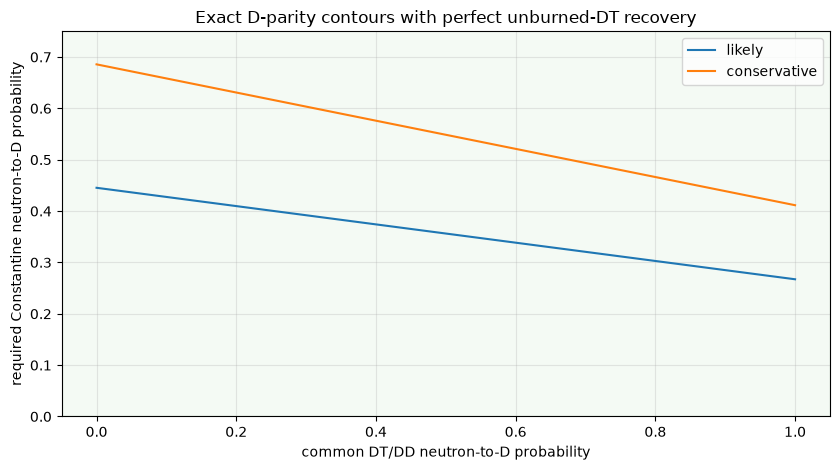

In [6]:
eta_aux = np.linspace(0.0, 1.0, 200)
fig, ax = plt.subplots(figsize=(8.5, 4.8))
for case, support in supports.items():
    required_eta_c = [constantine_efficiency_for_d_parity(
        support, eta_dt_n_to_d=value, eta_dd_n_to_d=value
    ) for value in eta_aux]
    ax.plot(eta_aux, required_eta_c, label=case)
ax.axhspan(0, 1, color='tab:green', alpha=0.05)
ax.set(xlabel='common DT/DD neutron-to-D probability', ylabel='required Constantine neutron-to-D probability',
       ylim=(0, 0.75), title='Exact D-parity contours with perfect unburned-DT recovery')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()

In [7]:
loss_rows = []
for case, support in supports.items():
    for recovery in (1.0, 0.999, 0.99, 0.90):
        ledger = evaluate_roman_closure(
            support, eta_constantine_n_to_d=0.8, eta_dt_n_to_d=0.8, eta_dd_n_to_d=0.8,
            unburned_dt_recovery=recovery, unburned_n15_recovery=recovery,
            unburned_catalyst_recovery=recovery,
        )
        loss_rows.append({
            'case': case, 'unburned-material recovery': recovery,
            'D consumed': ledger.d_total_consumed, 'G_D': ledger.g_d,
            'N15 makeup / traversal': ledger.n15_makeup_required,
            'total stable-catalyst makeup / traversal': sum(ledger.catalyst_makeup_required.values()),
        })
pd.DataFrame(loss_rows).set_index(['case', 'unburned-material recovery'])

D consumed       G_D  \
case         unburned-material recovery                         
likely       1.000                         0.445345  2.116362   
             0.999                         0.445456  2.115871   
             0.990                         0.446462  2.111465   
             0.900                         0.456519  2.068475   
conservative 1.000                         0.685715  1.486666   
             0.999                         0.686172  1.485782   
             0.990                         0.690286  1.477880   
             0.900                         0.731429  1.403750   

                                         N15 makeup / traversal  \
case         unburned-material recovery                           
likely       1.000                                     0.000000   
             0.999                                     0.001000   
             0.990                                     0.010000   
             0.900                                     0.100000   
conservative 1.000                                     0.000000   
             0.999                                     0.001857   
             0.990                                     0.018571   
             0.900                                     0.185714   

                                         total stable-catalyst makeup / traversal  
case         unburned-material recovery                                            
likely       1.000                                                        0.00000  
             0.999                                                        0.00500  
             0.990                                                        0.05000  
             0.900                                                        0.50000  
conservative 1.000                                                        0.00000  
             0.999                                                        0.00125  
             0.990                                                        0.01250  
             0.900                                                        0.12500

## Checkpoint conclusions

- The ideal heavy-isotope network closes exactly and has one gross D product and one net mainline alpha surplus.
- With perfect unburned-DT recovery, current DT burn is about 0.0891 pair/traversal likely and 0.1371 conservative. DD tritium closure therefore consumes about 0.445 and 0.686 D respectively.
- Even assigning zero credit to DT and DD neutrons, D parity requires Constantine neutron-to-recoverable-D probabilities of only about 0.445 and 0.686. Workbook 45 must determine whether the complete target and H blanket achieve those values.
- At 80% recovery for all neutron populations, both brackets are D-positive in this ledger. This is a conditional result, not transport proof.
- Perfect CNO closure requires recovery of unburned target material. Any loss creates explicit external isotope makeup.
- If failed attempts burn a full driver, the one-N15 budget requires equal shot success above approximately 99.69% likely or 95.93% conservative. Failed-shot pusher burn and recovery must therefore enter Workbook 80.